# **Predicting Smarthpone Addiction**

## **Data Exploration**

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head(10)

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
5,5,28.0,7.37,1.78,1.56,3.38,8.33,210.0,40.0,7.85,Male,High,No,0
6,6,18.0,4.24,1.61,1.14,0.91,5.09,220.0,68.0,7.46,Other,Low,Yes,0
7,7,25.0,10.79,3.92,2.48,3.61,7.20,195.0,NaN,13.45,Other,High,No,1
8,8,26.0,8.42,2.57,3.41,1.90,6.64,99.0,27.0,8.35,Other,Medium,Yes,0
9,9,20.0,8.74,1.40,2.43,2.11,8.57,NaN,109.0,10.68,Other,High,NaN,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [4]:
df.describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183466,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [5]:
df.isnull().sum()

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

In [6]:
df[df.isna().sum(axis=1) == 10]

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
8575,8575,32.0,NaN,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
95582,95582,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,NaN,NaN,0
138419,138419,NaN,12.11,NaN,NaN,NaN,NaN,242.0,NaN,NaN,NaN,NaN,NaN,1
142437,142437,NaN,NaN,NaN,NaN,NaN,NaN,211.0,143.0,NaN,NaN,NaN,NaN,0
145558,145558,34.0,NaN,NaN,NaN,NaN,8.22,NaN,NaN,NaN,NaN,NaN,NaN,1
236929,236929,NaN,NaN,NaN,NaN,2.85,NaN,NaN,NaN,9.05,NaN,NaN,NaN,1
260289,260289,NaN,NaN,NaN,0.13,NaN,NaN,NaN,NaN,NaN,NaN,Medium,NaN,1
308102,308102,NaN,8.33,NaN,NaN,NaN,NaN,NaN,144.0,NaN,NaN,NaN,NaN,1
394417,394417,NaN,NaN,NaN,NaN,2.93,NaN,NaN,127.0,NaN,NaN,NaN,NaN,1
396647,396647,NaN,NaN,NaN,NaN,NaN,4.66,NaN,NaN,NaN,Female,NaN,NaN,1


In [7]:
df[df.isna().sum(axis=1) == 9]

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
3051,3051,NaN,12.73,NaN,NaN,NaN,NaN,NaN,174.0,NaN,Other,NaN,NaN,1
4194,4194,25.0,11.36,NaN,NaN,NaN,NaN,NaN,NaN,14.37,NaN,NaN,NaN,1
11517,11517,NaN,NaN,NaN,NaN,NaN,NaN,213.0,NaN,NaN,NaN,Low,No,1
18162,18162,NaN,NaN,NaN,1.97,2.11,NaN,NaN,NaN,NaN,NaN,NaN,No,0
20146,20146,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,NaN,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654362,654362,18.0,10.56,NaN,2.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
658218,658218,21.0,NaN,NaN,NaN,NaN,7.47,NaN,NaN,NaN,Female,NaN,NaN,1
671475,671475,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.03,NaN,Medium,NaN,1
673844,673844,NaN,NaN,NaN,NaN,4.55,NaN,108.0,NaN,12.32,NaN,NaN,NaN,1


In [8]:
df[df.isna().sum(axis=1) == 8]

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
216,216,NaN,4.05,1.22,NaN,0.48,NaN,NaN,16.0,NaN,NaN,NaN,NaN,0
811,811,21.0,NaN,NaN,NaN,3.07,NaN,NaN,179.0,NaN,Male,NaN,NaN,1
861,861,35.0,NaN,2.44,NaN,NaN,NaN,NaN,NaN,10.83,Other,NaN,NaN,1
3638,3638,NaN,NaN,4.68,2.53,2.00,NaN,NaN,NaN,NaN,NaN,NaN,Yes,1
5106,5106,NaN,NaN,NaN,2.28,NaN,7.77,NaN,NaN,4.66,NaN,NaN,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683661,683661,NaN,NaN,NaN,NaN,0.88,NaN,167.0,NaN,NaN,Other,NaN,No,0
684727,684727,20.0,9.87,NaN,NaN,NaN,5.45,NaN,NaN,NaN,Other,NaN,NaN,1
685902,685902,26.0,NaN,NaN,NaN,3.26,NaN,NaN,NaN,NaN,Other,NaN,No,0
685955,685955,18.0,12.72,6.75,NaN,NaN,NaN,NaN,NaN,NaN,Other,NaN,NaN,1


In [9]:
df['gender'].value_counts()

gender
Male      223662
Female    221595
Other     217078
Name: count, dtype: int64

In [10]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df['gender'] = df['gender'].map({'Other': 0 , 'Male': 1 , 'Female': 2})
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['academic_work_impact'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})

ids = df['id']
df = df.drop('id', axis=1)

imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_array = imputer.fit_transform(df)

df = pd.DataFrame(imputed_array, columns=df.columns)

df['gender'] = df['gender'].round()

df = pd.get_dummies(df, columns=['gender'], dtype=float)

df.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addicted_label,gender_0.0,gender_1.0,gender_2.0
0,24.0,6.851669,1.830000,1.590000,2.110000,7.46,122.000000,38.000000,8.630000,1.0,0.00000,1.0,0.0,1.0,0.0
1,19.0,5.970000,1.080000,1.214960,3.030000,8.22,76.000000,19.000000,7.598724,1.0,0.00000,0.0,0.0,0.0,1.0
2,18.0,5.090000,1.373951,1.166042,1.873855,6.25,134.000000,60.000000,7.470000,0.0,1.00000,0.0,0.0,0.0,1.0
3,21.0,6.420000,1.260000,1.420000,3.360000,8.85,112.000000,94.000000,8.660000,0.0,0.48357,1.0,1.0,0.0,0.0
4,26.0,11.200000,1.870000,2.810000,1.950000,5.25,149.064353,105.620326,13.390000,1.0,0.00000,1.0,0.0,0.0,1.0


In [11]:
df.isnull().sum()

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
addicted_label             0
gender_0.0                 0
gender_1.0                 0
gender_2.0                 0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      691369 non-null  float64
 1   daily_screen_time_hours  691369 non-null  float64
 2   social_media_hours       691369 non-null  float64
 3   gaming_hours             691369 non-null  float64
 4   work_study_hours         691369 non-null  float64
 5   sleep_hours              691369 non-null  float64
 6   notifications_per_day    691369 non-null  float64
 7   app_opens_per_day        691369 non-null  float64
 8   weekend_screen_time      691369 non-null  float64
 9   stress_level             691369 non-null  float64
 10  academic_work_impact     691369 non-null  float64
 11  addicted_label           691369 non-null  float64
 12  gender_0.0               691369 non-null  float64
 13  gender_1.0               691369 non-null  float64
 14  gend

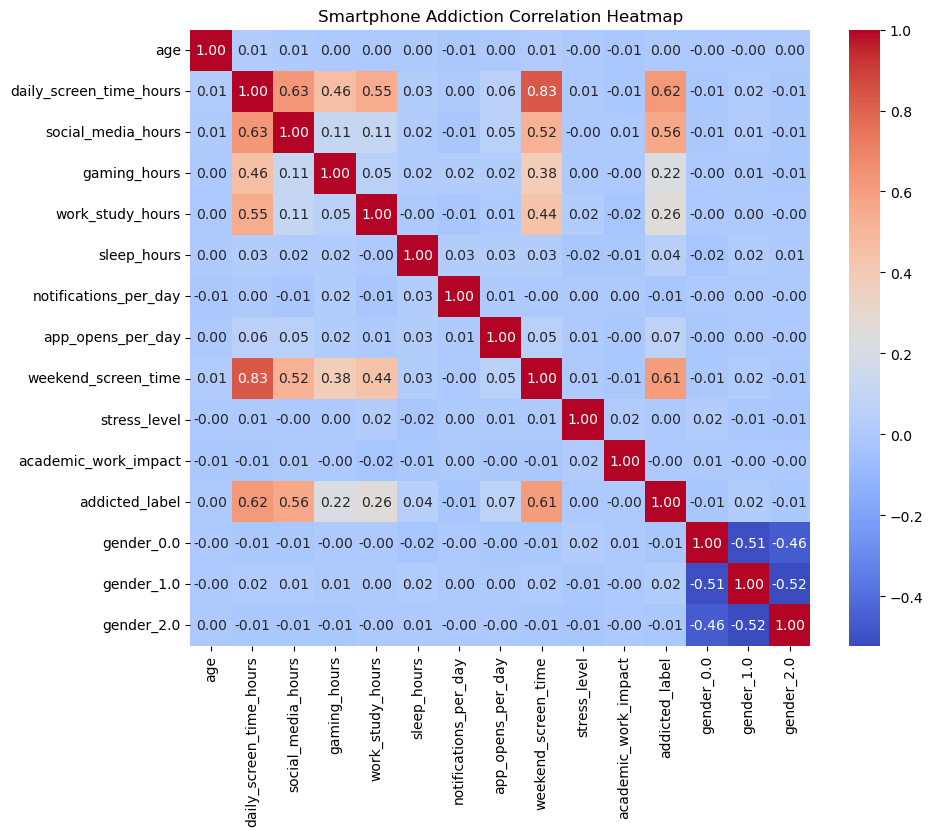

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Smartphone Addiction Correlation Heatmap")
plt.show()

In [14]:
X_train = df.drop(columns=['addicted_label'])
y_train = df['addicted_label']

In [15]:
%pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [16]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score


rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
lgbm_model = LGBMClassifier(n_estimators=100, max_depth=6, n_jobs=-1, random_state=42)
Grad_Boost = GradientBoostingClassifier(random_state=42)



models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Gradient Boosting": Grad_Boost,
}

print("--- MODEL ACCURACY SCORES (Out of 100%) ---")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (Stability: +/- {scores.std():.4f})")

--- MODEL ACCURACY SCORES (Out of 100%) ---
Random Forest: 0.9069 (Stability: +/- 0.0003)
XGBoost: 0.9283 (Stability: +/- 0.0003)
[LightGBM] [Info] Number of positive: 326982, number of negative: 133930
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2769
[LightGBM] [Info] Number of data points in the train set: 460912, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892588
[LightGBM] [Info] Start training from score 0.892588
[LightGBM] [Info] Number of positive: 326983, number of negative: 133930
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [

In [17]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_jobs=-1,
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV accuracy:")
print(grid_search.best_score_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}

Best CV accuracy:
0.9342840067632084


In [18]:
best_xgb = grid_search.best_estimator_

## Preparing test dataset 

In [19]:
test = pd.read_csv('test.csv')
test.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [20]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

test['gender'] = test['gender'].map({'Other': 0 , 'Male': 1 , 'Female': 2})
test['stress_level'] = test['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
test['academic_work_impact'] = test['academic_work_impact'].map({'No': 0, 'Yes': 1})

id_test = test['id']
test = test.drop('id', axis=1)

imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_array = imputer.fit_transform(test)

test = pd.DataFrame(imputed_array, columns=test.columns)

test['gender'] = test['gender'].round()

test = pd.get_dummies(test, columns=['gender'], dtype=float)

test.head()

c:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,gender_0.0,gender_1.0,gender_2.0
0,30.000000,9.340000,2.84047,0.770000,4.09,7.15,153.0,16.0,10.905304,1.00000,1.0,1.0,0.0,0.0
1,26.629443,7.317428,1.91000,1.903999,1.20,8.67,239.0,148.0,10.680000,2.00000,0.0,0.0,0.0,1.0
2,26.000000,8.480000,3.64000,1.033233,3.39,7.47,106.0,123.0,10.169114,1.00928,0.0,0.0,1.0,0.0
3,20.000000,8.370000,2.99000,1.690000,2.53,5.45,178.0,55.0,9.880000,2.00000,1.0,0.0,1.0,0.0
4,25.000000,8.250000,4.02000,1.210000,2.32,8.46,63.0,86.0,10.720000,0.00000,0.0,0.0,1.0,0.0


In [21]:
test.isnull().sum()

age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
stress_level               0
academic_work_impact       0
gender_0.0                 0
gender_1.0                 0
gender_2.0                 0
dtype: int64

In [22]:
predictions = best_xgb.predict(test)

In [23]:
original_test_data = pd.read_csv('test.csv')

submission = pd.DataFrame({
    'id': original_test_data['id'],
    'addicted_label': predictions
})

submission.to_csv('submission2.csv', index=False)
print("file submission created successfully.")

file submission created successfully.
